In [27]:
import pandas as pd

# Loading the data
invoice_df = pd.read_csv('/Users/sebiesanchez/Downloads/fct_invoice.csv')
customers_df = pd.read_json('/Users/sebiesanchez/Downloads/dim_customer.json')

# Rename id to customer_id in customers_df for merging
customers_df.rename(columns={'id': 'customer_id'}, inplace=True)

# Merge the two DataFrames baesd on customer_id
merged_df = invoice_df.merge(customers_df, on='customer_id', how='inner')

# Preview the merged result
merged_df.head()


,invoice_no,customer_id,category,quantity,price,payment_method,invoice_date,shopping_mall,age,first_name,gender,last_name
0,I138884,229,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,NaN,William,M,Anderson
1,I317333,3433,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,34.0,Danielle,F,Rivera
2,I127801,644,Clothing,1,300.08,Cash,9/11/2021,Metrocity,46.0,Christopher,M,Stephens
3,I173702,4900,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,46.0,Laura,F,Kelly
4,I337046,1089,Books,4,60.60,Cash,24/10/2021,Kanyon,NaN,Richard,M,Rhodes


In [28]:
#1. How many unique customers are in the dataset?

unique_customers = merged_df['customer_id'].nunique()
print(f"The number of unique customers: {unique_customers}")


The number of unique customers: 5191


In [32]:
#2. What are the different categories of products available? How many unique categories are there?

categories = merged_df['category'].unique()
num_categories = merged_df['category'].nunique()

print(f"Categories:", categories)
print(f" The number of unique categories:", num_categories)


Categories: ['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']
 The number of unique categories: 8


In [36]:
#3. Which payment method is the most popular? How many times was it used?



counts = merged_df['payment_method'].value_counts()
most_popular_method = counts.idxmax()  # the method name
method_count = counts.max()            # how many times

print(f"The most popular payment method: {most_popular_method}. It was used {method_count} times")



The most popular payment method: Cash. It was used 44447 times


In [51]:
#1. What are the three most popular categories, by total sales?

# Merging quanity and price together into one column

merged_df['total_sale'] = merged_df['quantity'] * merged_df['price']

# Filtering 
popular_categories = merged_df.groupby('category')['total_sale'].sum().sort_values(ascending=False).head(3)

# Convert Series to DataFrame
popular_categories_df = popular_categories.reset_index()

# Rename columns
popular_categories_df.columns = ['category', 'total_sales']

# Display the result
print(popular_categories_df)

     category   total_sales
0    Clothing  1.139968e+08
1       Shoes  6.655345e+07
2  Technology  5.786235e+07


In [56]:
#2. What are the total sales attributed to customers over the age of 45?

# Filter data and ensure it is numbers to be compared to the age
sales_over_45 = merged_df[merged_df['age'] > 45]['total_sale'].sum()
print(f"The total sales from customers over 45: {sales_over_45}")



Total sales from customers over 45: 82039768.15


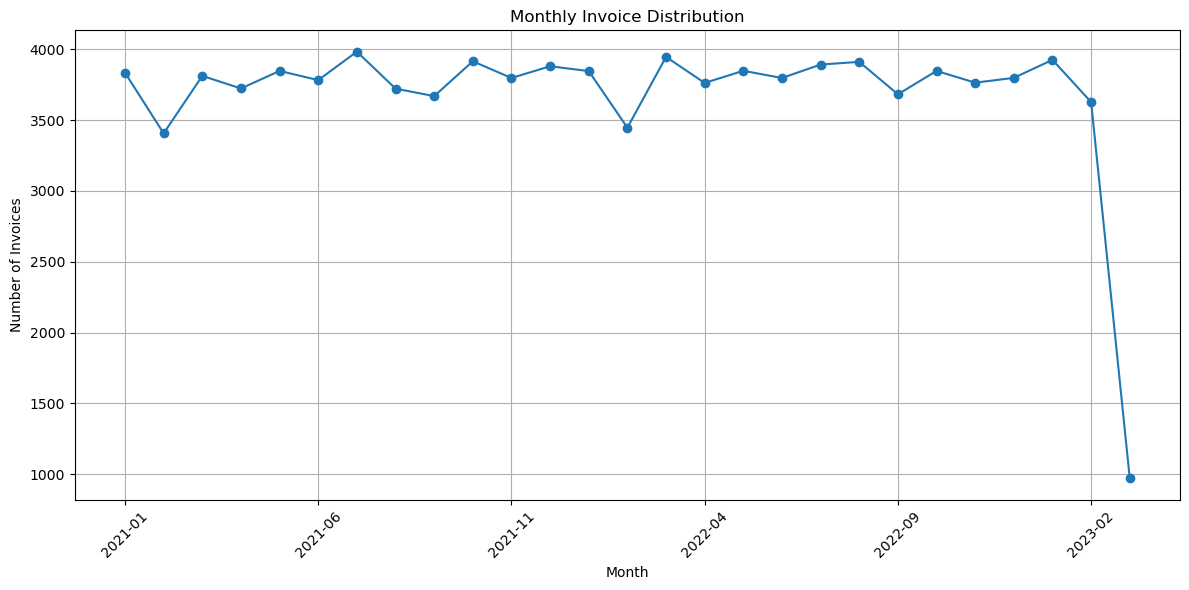

In [66]:
# 3. How is the data distributed across different invoice dates? Are there any seasonal trends or patterns? (Use a graph for this.)

import matplotlib.pyplot as plt

# Formats the invoice_date column in datetime format
merged_df['invoice_date'] = pd.to_datetime(merged_df['invoice_date'], dayfirst=True)

# Group by month and count the number of invoices
monthly_invoices = merged_df.groupby(pd.Grouper(key='invoice_date', freq='ME')).size()

# Format the index to display year and month
monthly_invoices.index = monthly_invoices.index.strftime('%Y-%m')

# Create the plot
plt.figure(figsize=(12, 6))
monthly_invoices.plot(kind='line', marker='o', linestyle='-')

# Add titles and labels
plt.title('Monthly Invoice Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Invoices')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

In [81]:
# 1. Create a pivot table showing the breakdown of sales across these dimensions, in this order: category, decade age range (e.g., 10-19, 20-29, and so forth).

# Group age into brackets
def categorize_by_age(value):
    if pd.isna(value):
        return None
    lower_bound = (int(value) // 10) * 10
    upper_bound = lower_bound + 9
    return f"{lower_bound}-{upper_bound}"

# Apply the age category to the dataset
merged_df['age_bracket'] = merged_df['age'].map(categorize_by_age)

# Summarize total sales by product category and age bracket
age_sales_summary = pd.pivot_table(
    data=merged_df,
    index='category',          
    columns='age_bracket',      
    values='total_sale',       
    aggfunc='sum',            
    fill_value=0                # replace NaN with 0
)

# Show the resulting pivot table
age_sales_summary


age_bracket,10-19,20-29,30-39,40-49,50-59,60-69,70-79,80-89
category,,,,,,,,
Books,12801.75,79461.75,84143.10,87203.40,74962.20,80476.80,54827.85,26664.00
Clothing,1927413.84,10250732.80,11354126.96,11215189.92,10321851.76,10660642.08,7769371.28,4493698.00
Cosmetics,109619.36,605915.32,723544.70,665034.96,587780.96,649990.76,419082.62,254531.60
Food & Beverage,13582.31,73491.96,87246.86,89553.29,72425.04,80976.09,55050.98,31332.93
Shoes,993281.35,5924878.24,7200839.66,7025590.02,5852857.84,5978893.54,4480269.05,2628744.60
Souvenir,12375.15,54943.32,64092.72,66391.80,54943.32,55025.43,38673.81,23718.06
Technology,1129800.00,5261550.00,6159300.00,5954550.00,4435200.00,5471550.00,3638250.00,1946700.00
Toys,60426.24,385100.80,420582.40,390906.88,345067.52,363955.20,273244.16,153932.80
